In [252]:
import numpy as np
from scipy import fft
from matplotlib import pyplot as plt
import scipy.io

In [253]:
rootfolder = './data'

Generating 1-D DCT basis
------------------------


In [254]:
M = 128 # signal dimension
N = M # nr of atoms in the basis (this will be different when using redundant set of generators)

D = np.zeros((M, N)) # matrix containing the DCT basis (a DCT function in each column)
DCT = np.zeros((M, N)) # matrix containing the standard basis (a kronecker delta in each column)


c0 = np.sqrt(1/M) # normalization when k = 0
c = np.sqrt(2/M) # Normalize when k > 0


for k in range(M):
    # take the formula from slides and remember to normalize. Each atom goes in a column of DCT matrix
    DCT[:, k] =  [c0 * np.cos(k * np.pi * (2*n + 1)/(2*M)) if k == 0 else c * np.cos(k * np.pi * (2*n + 1)/(2*M))  for n in range(M)]    # Take in consideration the different normalization


# # Second version no compact    
#     for n in range (N):
#         c_used = c
#         if n == 0:
#             c_used = c0
#         DCT[n, k] =  np.cos(k * np.pi * (2*n + 1)/(2*M))


    norm = np.linalg.norm(DCT, axis=0)
    DCT = DCT /norm

/tmp/ipykernel_12397/824044720.py:26: RuntimeWarning: invalid value encountered in divide
  DCT = DCT /norm


Display an atom of the dct basis

Text(0.5, 1.0, 'element: 35 from the DCT basis')

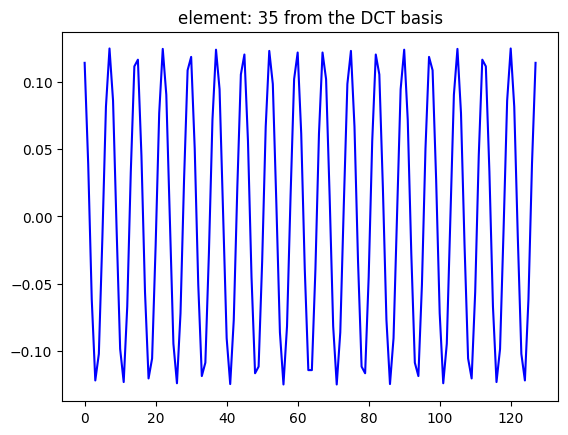

In [255]:
k = 34
plt.figure()
plt.plot(DCT[:, k], 'b')
plt.title(f'element: {k+1} from the DCT basis')

Check orthogonality

In [256]:
is_DCT_orth = np.alltrue(np.identity(M) == (np.matmul(DCT , DCT.T)).round())

# Second way to compute the orthogonal property
#is_DCT_orth = np.allclose((np.matmul(DCT , DCT.T)) , np.identity(M)) 

print(f'DCT dictionary is orthogonal: {is_DCT_orth}')

DCT dictionary is orthogonal: True


Display the basis in the matrix

Text(0.5, 1.0, 'DCT basis, atoms in the column')

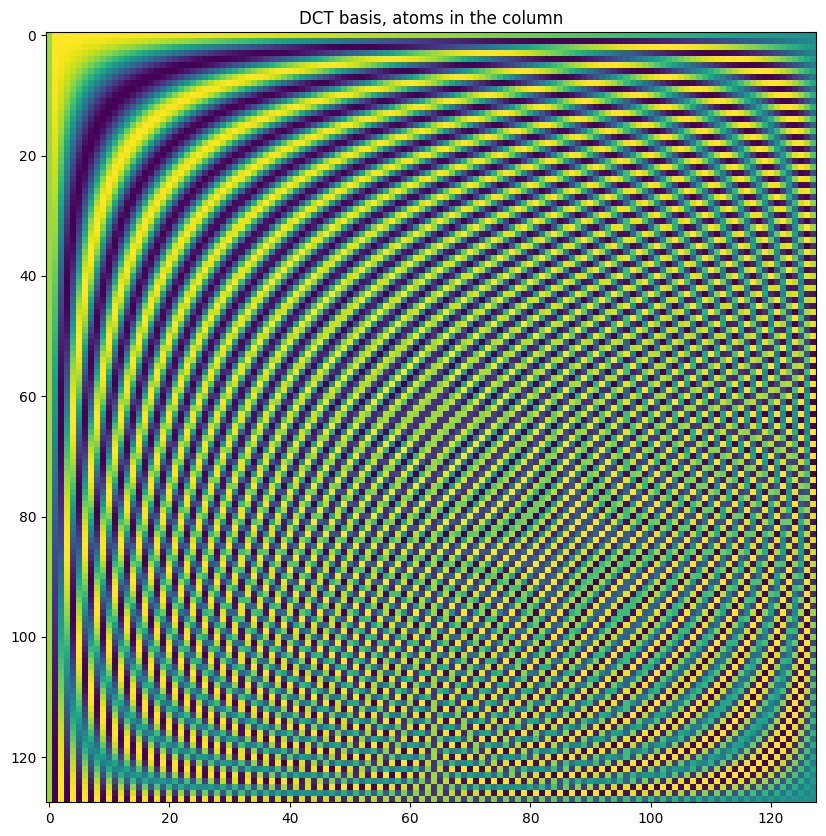

In [257]:
plt.figure(figsize=(10,10))
plt.imshow(DCT)
plt.title('DCT basis, atoms in the column')

Generate 1D DCT basis using the function idct
---------------------------------------------
idct is the inverse dct transform stack this in the matrix D

In [258]:
for k in range(M):
    # define the atom
    a = np.zeros(M)
    a[k] = 1
    D[:, k] = fft.idct(a, norm='ortho')


Display the basis in the matrix

Text(0.5, 1.0, 'DCT basis, atoms in the column')

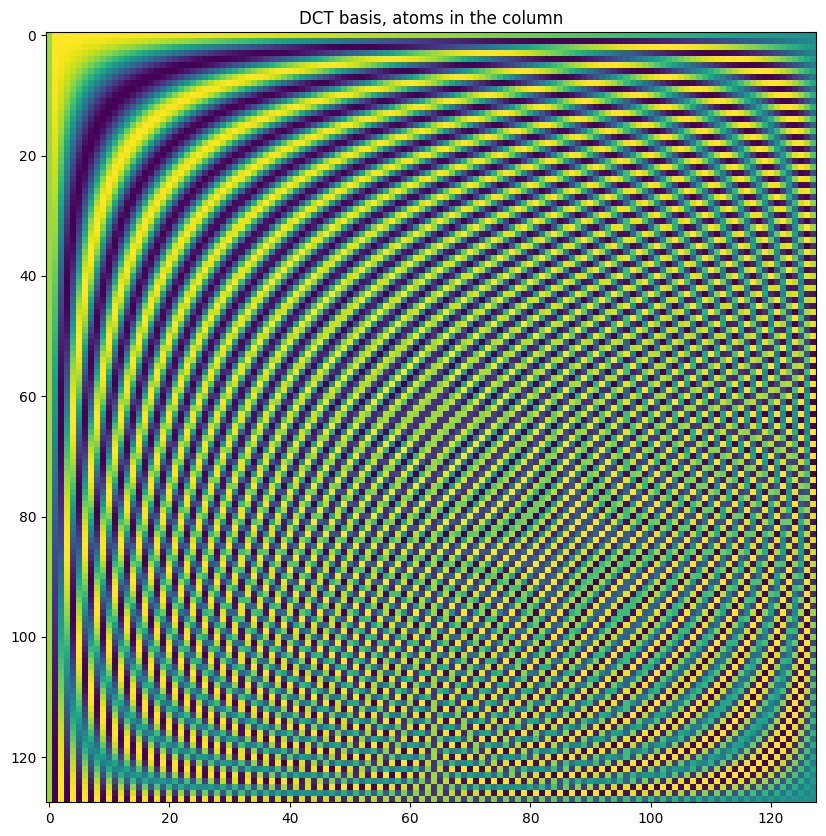

In [259]:
plt.figure(figsize=(10,10))
plt.imshow(DCT)
plt.title('DCT basis, atoms in the column')

Check that D and DCT defined above coincide

In [260]:
is_DCT_equal_D = np.allclose(D,DCT)
print(f'D and DCT are equal: {is_DCT_equal_D}')

D and DCT are equal: True


Analysis: compute the representation of an input ECG signal
-----------------------------------------------------------
Load few ECG signals to be processed

In [261]:
temp = scipy.io.loadmat(f'{rootfolder}/croppedECG.mat')
nBeats = 10
S = temp['S'][:, :nBeats]
X = np.zeros((M, nBeats)) # initialize the matrix of representations of S w.r.t. D


Compute the representation coefficients

In [262]:
for i in range(nBeats):
    X[:, i] = DCT.T @ S[:,i]

Display a signal and its representation coefficients

Text(0.5, 1.0, 'coefficients w.r.t. DCT basis')

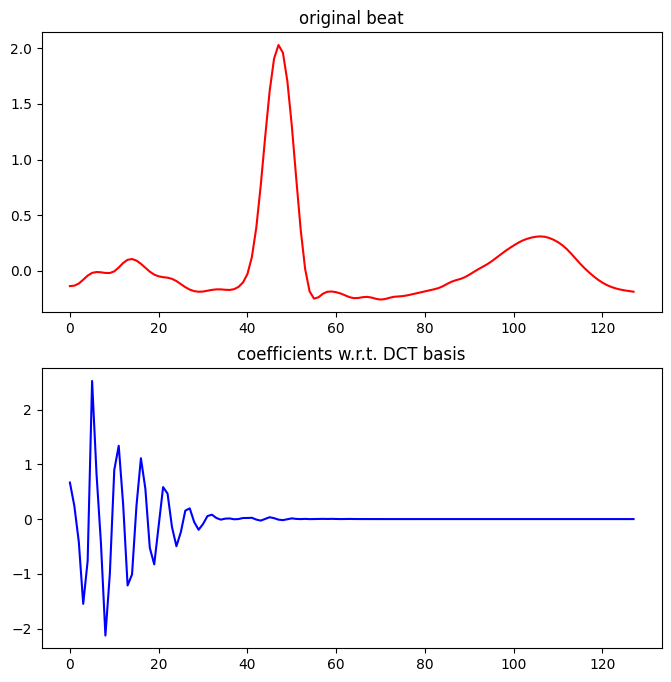

In [263]:
i = 5
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.plot(S[:, i], 'r')
ax1.set_title('original beat')
ax2.plot(X[:, i], 'b')
ax2.set_title('coefficients w.r.t. DCT basis')

Synthesis: reconstruct all the ECG signals from their representations
---------------------------------------------------------------------
Reconstruct the two signals (express them w.r.t. the standard basis)

In [264]:
S_hat_D = DCT @ DCT.T @ S       ## Or simple DCT @ X

Check if there is perfect reconstruction.

It is trivial because $\hat S_D = DD^TS$ and $DD^T = I_M$  since $D$ is orthonormal (the same applies to $C$)

In [265]:
is_reconstruction_perfect = np.allclose(S_hat_D,  S)
print(f'The reconstruction is perfect: {is_reconstruction_perfect}')

The reconstruction is perfect: True


Add noise to ECG data and inspect the representations
-----------------------------------------------------


In [266]:
sigma_noise = 0.1
S0 = S.copy()
S = S0 + sigma_noise * np.random.normal(size=S0.shape)

X = np.zeros((M, nBeats)) # initialize the matrix of representations of S w.r.t. D


Compute the representation coefficients

In [276]:
for i in range(nBeats):
    X[:, i] = DCT.T @ S[:,i]

Display a signal and its representation coefficients

Text(0.5, 1.0, 'coefficients w.r.t. DCT basis')

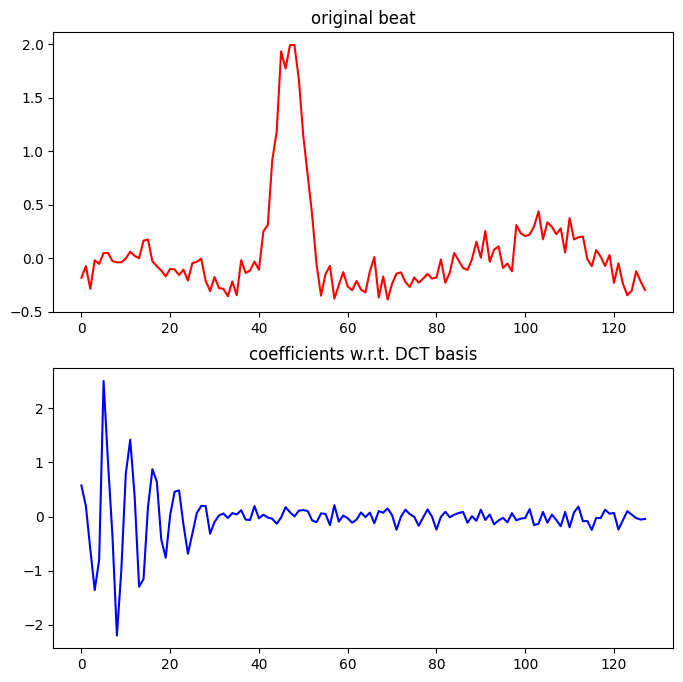

In [277]:
i = 5
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))
ax1.plot(S[:, i], 'r')
ax1.set_title('original beat')
ax2.plot(X[:, i], 'b')
ax2.set_title('coefficients w.r.t. DCT basis')

Hard Thresholding
-----------------
Noise affects all the coefficients of our transformation

Keep only $L$ coefficients having largest magnitude

In [281]:
X_HT = np.zeros((M, nBeats)) # initialize the matrix of representations of S w.r.t. D
S_hat = np.zeros((M, nBeats))
L = 21 # sparsity level (try different values)

for i in range(nBeats):
    origSignal = S0[:,i]
    noisySignal = S[:,i]

    # transform each signal separately (analysis)
    x = DCT.T @ noisySignal
    
    # keep only the L largest coefficients (absolute value)
    X_HT[:, i] = x * (np.abs(x)>= np.sort(np.abs(x))[-L])

    #print(X_HT[:,i])
    # invert the transformation
    s_hat = DCT @ X_HT[:, i]

    S_hat[:, i] = s_hat


Display a signal

Text(0.5, 1.0, 'DCT coefficients')

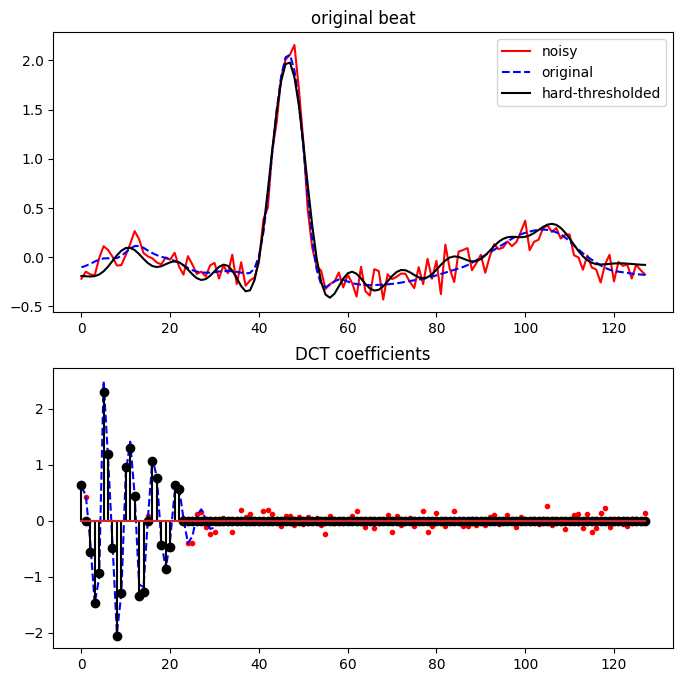

In [282]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))
ax1.plot(S[:, i], 'r')
ax1.plot(S0[:, i], 'b--')
ax1.plot(S_hat[:, i], 'k')
ax1.legend(['noisy', 'original', 'hard-thresholded'])
ax1.set_title('original beat')

# coefficients of the noisy signal
ax2.plot(np.matmul(D.T, S[:, i]), 'r.')
# coefficients of the noise free signal
ax2.plot(np.matmul(D.T, S0[:, i]), 'b--')
ax2.stem(np.arange(M), X_HT[:, i], 'k')
ax2.set_title('DCT coefficients')

Compression
-----------
Try to compress a heartbeat using different value of $L$ and plot the mean squared error corresponding to each $L$

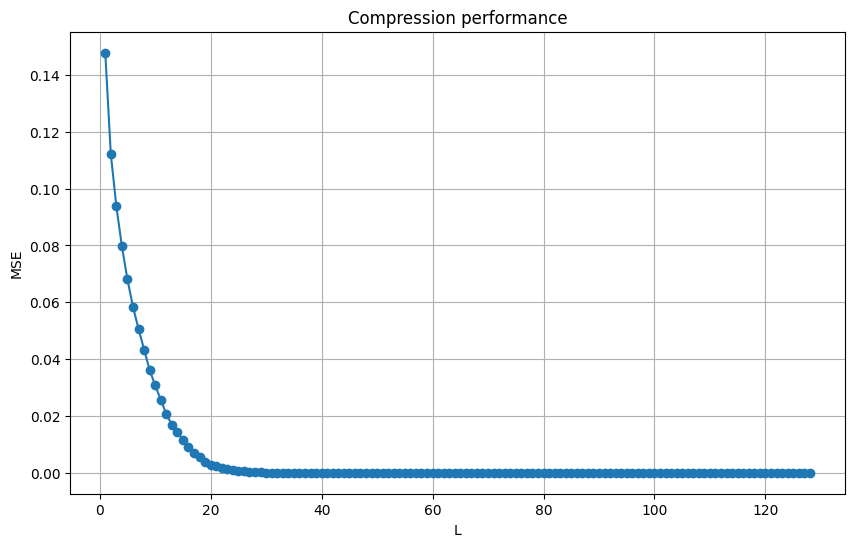

In [271]:
x_HT = np.zeros((M)) # initialize the matrix of representations of S w.r.t. D
s_hat = np.zeros((M))

L_values = np.arange(1, M+1)
MSE_values = np.zeros(M)

origSignal = S0[:, 0]

for L in L_values:
     # transform each signal separately (analysis)
    x = DCT.T @ origSignal

    # keep only the L largest coefficients (absolute value)
    #[...]

    x_HT = x * (np.abs(x)>= np.sort(np.abs(x))[-L])

    # invert the transformation
    s_hat = DCT @ x_HT

    
    mse = 1/M * np.sum((origSignal - s_hat)**2)

    MSE_values[L-1] = mse

plt.figure(figsize=(10,6))
plt.plot(L_values, MSE_values, '-o')
plt.xlabel('L')
plt.ylabel('MSE')
plt.title('Compression performance')
plt.grid()